In [11]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# Explainability
import shap

import warnings
warnings.filterwarnings("ignore")

In [12]:
df = pd.read_csv(r"C:\Users\priti\Downloads\default of credit card clients.csv")
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [13]:
df.columns

Index(['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19',
       'X20', 'X21', 'X22', 'X23', 'Y'],
      dtype='object')

In [14]:
df.columns = df.iloc[0]
df = df.drop(0).reset_index(drop=True)

In [15]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object', name=0)

In [16]:
df.rename(columns={
    'LIMIT_BAL': 'credit_limit',
    'SEX': 'gender',
    'EDUCATION': 'education_level',
    'MARRIAGE': 'marital_status',
    'AGE': 'age',
    
    'PAY_0': 'delay_sep',
    'PAY_2': 'delay_aug',
    'PAY_3': 'delay_jul',
    'PAY_4': 'delay_jun',
    'PAY_5': 'delay_may',
    'PAY_6': 'delay_apr',
    
    'BILL_AMT1': 'bill_sep',
    'BILL_AMT2': 'bill_aug',
    'BILL_AMT3': 'bill_jul',
    'BILL_AMT4': 'bill_jun',
    'BILL_AMT5': 'bill_may',
    'BILL_AMT6': 'bill_apr',
    
    'PAY_AMT1': 'pay_sep',
    'PAY_AMT2': 'pay_aug',
    'PAY_AMT3': 'pay_jul',
    'PAY_AMT4': 'pay_jun',
    'PAY_AMT5': 'pay_may',
    'PAY_AMT6': 'pay_apr',
    
    'default.payment.next.month': 'is_default'
}, inplace=True)

In [17]:
df.columns

Index(['ID', 'credit_limit', 'gender', 'education_level', 'marital_status',
       'age', 'delay_sep', 'delay_aug', 'delay_jul', 'delay_jun', 'delay_may',
       'delay_apr', 'bill_sep', 'bill_aug', 'bill_jul', 'bill_jun', 'bill_may',
       'bill_apr', 'pay_sep', 'pay_aug', 'pay_jul', 'pay_jun', 'pay_may',
       'pay_apr', 'default payment next month'],
      dtype='object', name=0)

In [18]:
df = df.apply(pd.to_numeric, errors='ignore')

In [19]:
df.isnull().sum()

0
ID                            0
credit_limit                  0
gender                        0
education_level               0
marital_status                0
age                           0
delay_sep                     0
delay_aug                     0
delay_jul                     0
delay_jun                     0
delay_may                     0
delay_apr                     0
bill_sep                      0
bill_aug                      0
bill_jul                      0
bill_jun                      0
bill_may                      0
bill_apr                      0
pay_sep                       0
pay_aug                       0
pay_jul                       0
pay_jun                       0
pay_may                       0
pay_apr                       0
default payment next month    0
dtype: int64

In [20]:
df['education_level'] = df['education_level'].replace([0,5,6], 4)
df['marital_status'] = df['marital_status'].replace(0, 3)

In [21]:
df.drop('ID', axis=1, inplace=True)

In [22]:
df.columns

Index(['credit_limit', 'gender', 'education_level', 'marital_status', 'age',
       'delay_sep', 'delay_aug', 'delay_jul', 'delay_jun', 'delay_may',
       'delay_apr', 'bill_sep', 'bill_aug', 'bill_jul', 'bill_jun', 'bill_may',
       'bill_apr', 'pay_sep', 'pay_aug', 'pay_jul', 'pay_jun', 'pay_may',
       'pay_apr', 'default payment next month'],
      dtype='object', name=0)

In [23]:
df.describe()

,credit_limit,gender,education_level,marital_status,age,delay_sep,delay_aug,delay_jul,delay_jun,delay_may,...,bill_jun,bill_may,bill_apr,pay_sep,pay_aug,pay_jul,pay_jun,pay_may,pay_apr,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.842267,1.557267,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.744494,0.521405,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [24]:
df.columns = df.columns.str.strip()

In [25]:
df.rename(columns={
    'default payment next month': 'is_default'
}, inplace=True)

In [26]:
df.columns

Index(['credit_limit', 'gender', 'education_level', 'marital_status', 'age',
       'delay_sep', 'delay_aug', 'delay_jul', 'delay_jun', 'delay_may',
       'delay_apr', 'bill_sep', 'bill_aug', 'bill_jul', 'bill_jun', 'bill_may',
       'bill_apr', 'pay_sep', 'pay_aug', 'pay_jul', 'pay_jun', 'pay_may',
       'pay_apr', 'is_default'],
      dtype='object', name=0)

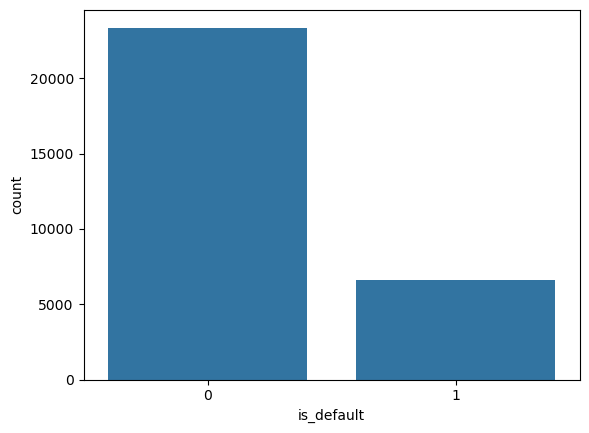

In [27]:
sns.countplot(x='is_default', data=df)
plt.show()

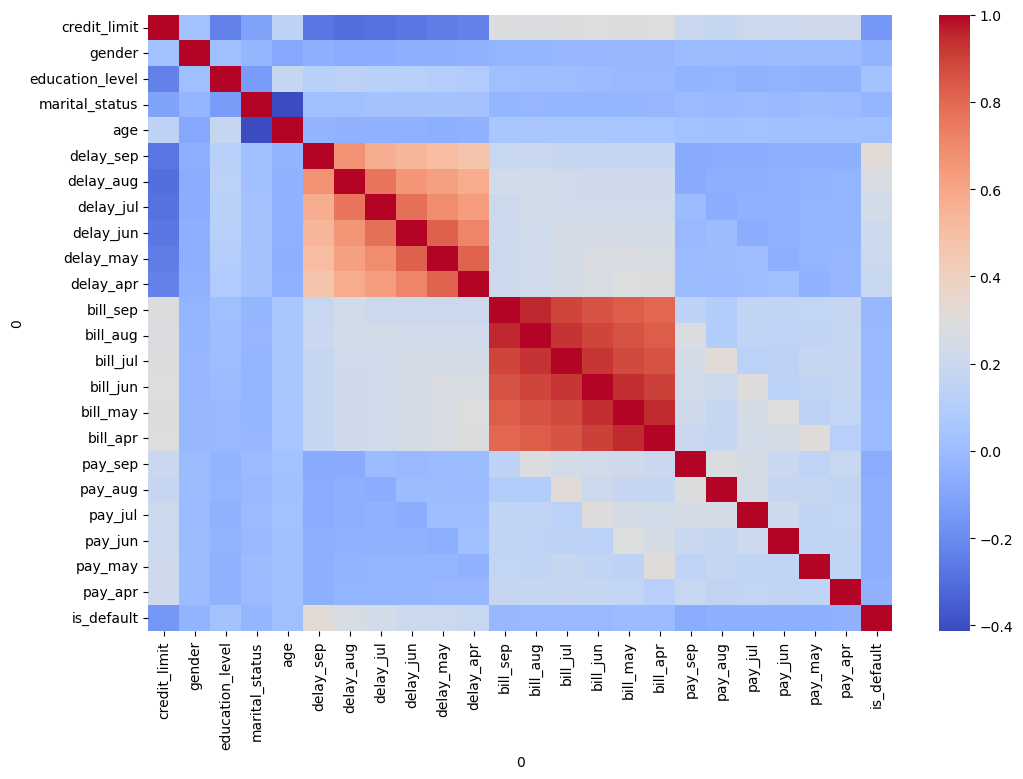

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

WE CAN SEE THAT MANY COLUMNS ARE CORRELATED TO EACH OTHER BY LOOKING AT THE DARK RED SQUARES IN THE MIDDLE, THEREFORE WE DONT NEED ALL THE COLUMNS AND THEREFORE WE WILL DECREASE THE DIMENSIONALITY OF THE DATASET AND CREATE NEW FEATURES INSTEAD OF USING SO MANY CORRELATED FEATURES.

ALSO WE CAN SEE WHICH COLUMNS AFFECT THE is_default COLUMN THE MOST

<h1 align="center"> NOW WE WILL DO FEATURE ENGINEERING + OUTLIERS HANDLING</h1>

In [29]:
delay_cols = ['delay_sep','delay_aug','delay_jul','delay_jun','delay_may','delay_apr']
bill_cols = ['bill_sep','bill_aug','bill_jul','bill_jun','bill_may','bill_apr']
pay_cols = ['pay_sep','pay_aug','pay_jul','pay_jun','pay_may','pay_apr']

In [30]:
df['avg_delay'] = df[delay_cols].mean(axis=1)
df['delay_count'] = (df[delay_cols] > 0).sum(axis=1)

df['total_bill'] = df[bill_cols].sum(axis=1)
df['total_payment'] = df[pay_cols].sum(axis=1)

df['payment_ratio'] = df['total_payment'] / (df['total_bill'] + 1)
df['utilization_ratio'] = df['bill_sep'] / df['credit_limit']
df['payment_consistency'] = df['total_payment'] / (df['credit_limit'] + 1)

In [31]:
df.columns

Index(['credit_limit', 'gender', 'education_level', 'marital_status', 'age',
       'delay_sep', 'delay_aug', 'delay_jul', 'delay_jun', 'delay_may',
       'delay_apr', 'bill_sep', 'bill_aug', 'bill_jul', 'bill_jun', 'bill_may',
       'bill_apr', 'pay_sep', 'pay_aug', 'pay_jul', 'pay_jun', 'pay_may',
       'pay_apr', 'is_default', 'avg_delay', 'delay_count', 'total_bill',
       'total_payment', 'payment_ratio', 'utilization_ratio',
       'payment_consistency'],
      dtype='object', name=0)

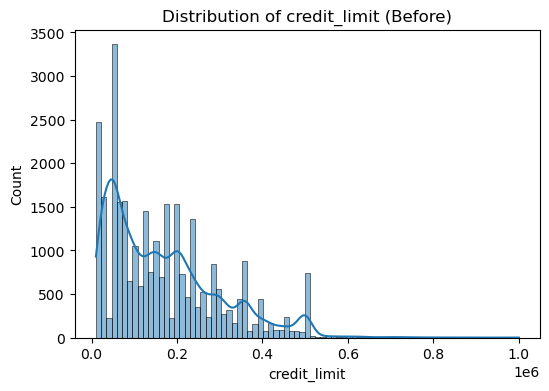

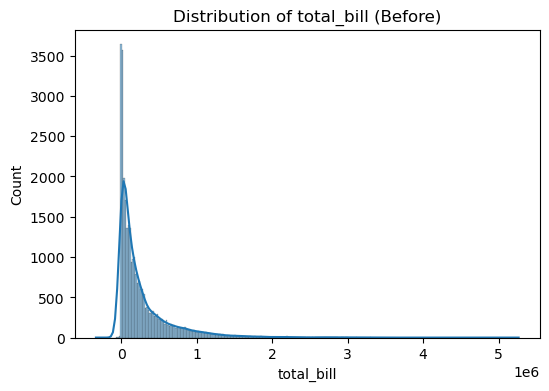

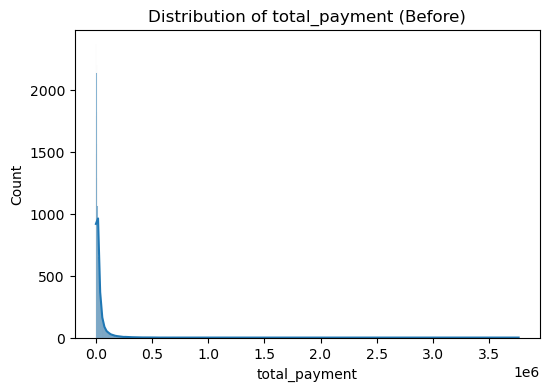

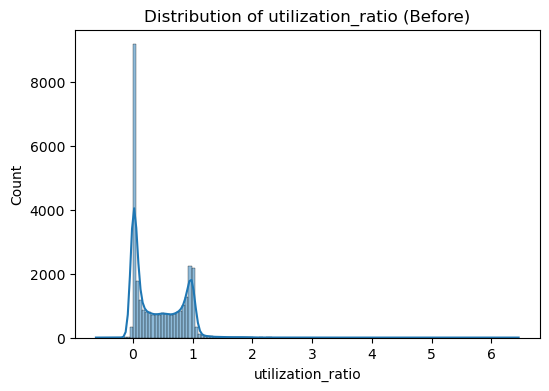

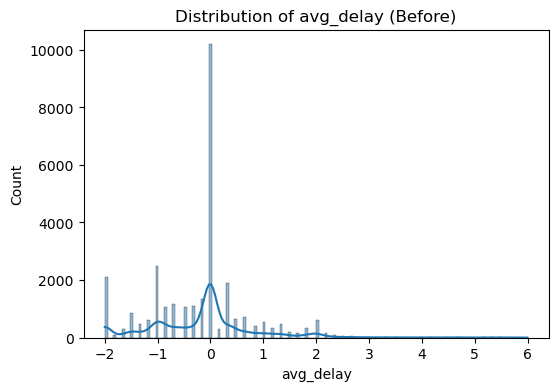

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['credit_limit', 'total_bill', 'total_payment', 'utilization_ratio', 'avg_delay']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col} (Before)')
    plt.show()

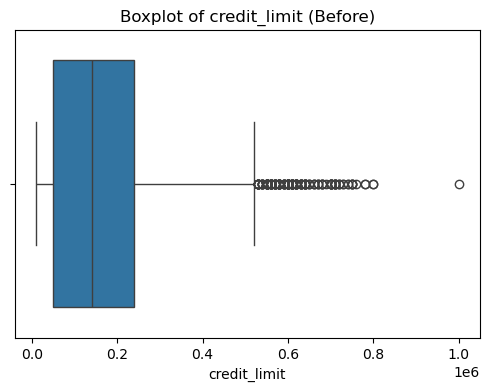

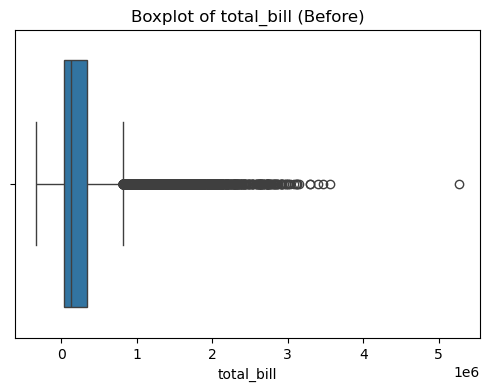

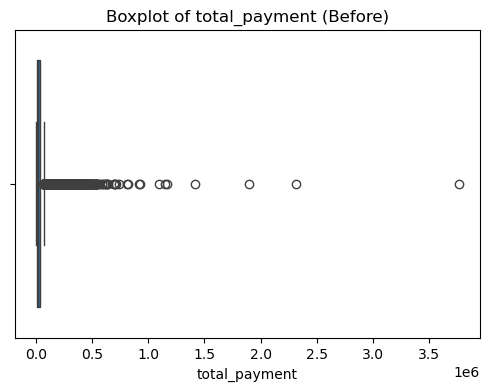

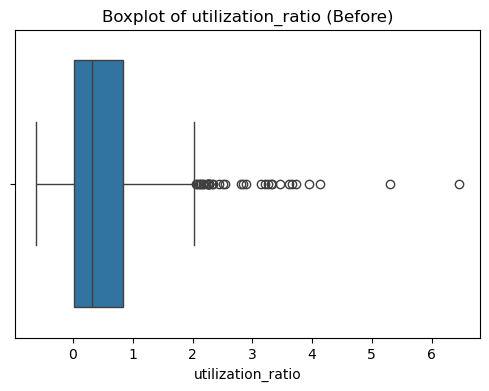

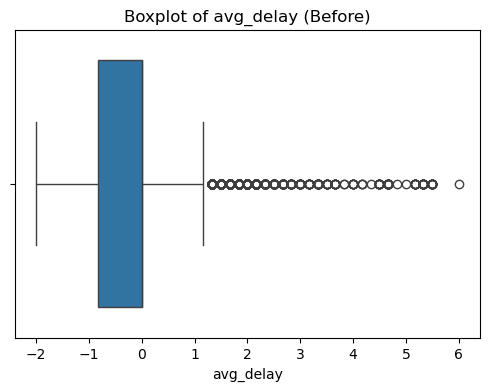

In [33]:
for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} (Before)')
    plt.show()

In [34]:
for col in cols:
    upper_limit = df[col].quantile(0.99)
    lower_limit = df[col].quantile(0.01)
    
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

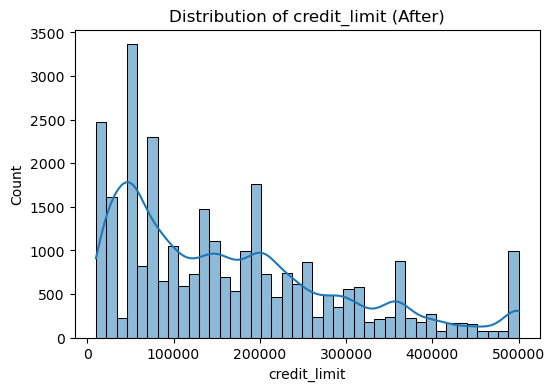

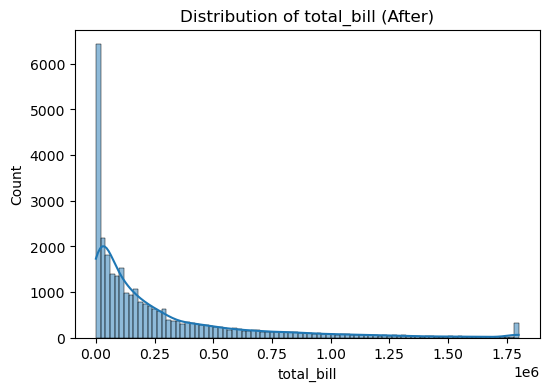

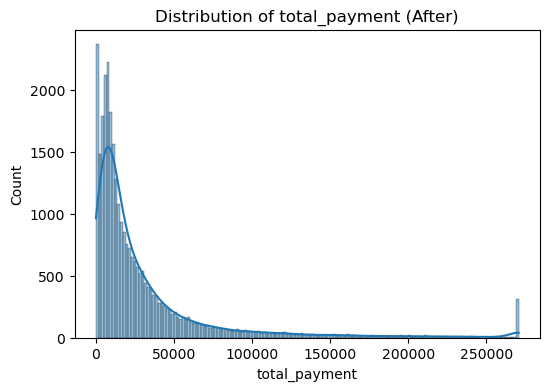

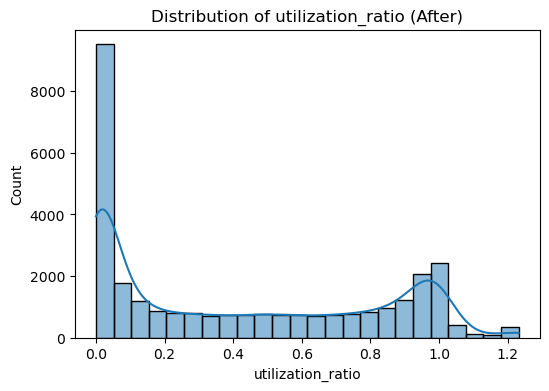

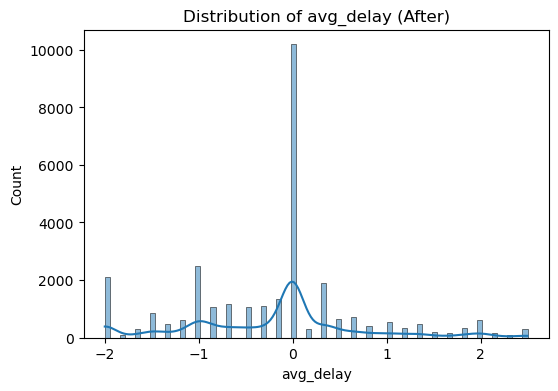

In [35]:
for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col} (After)')
    plt.show()

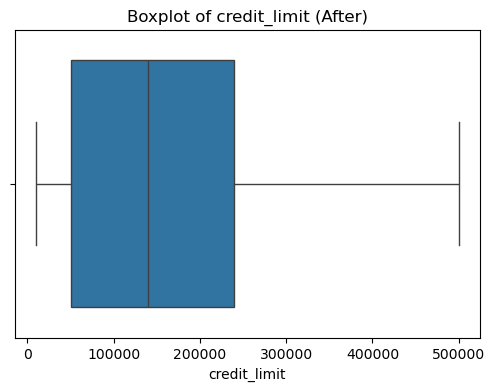

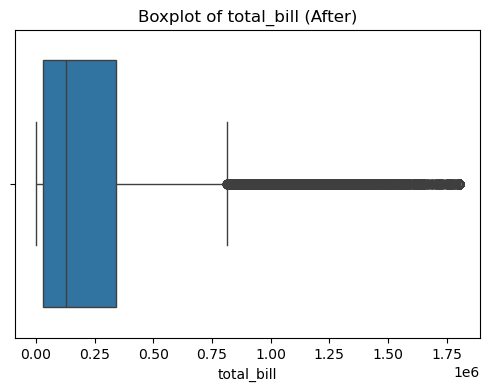

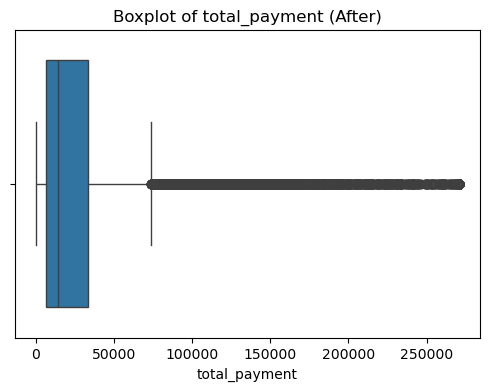

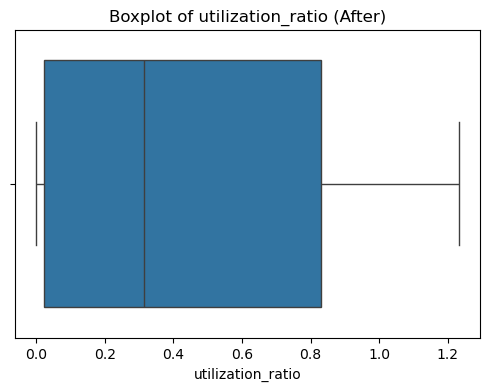

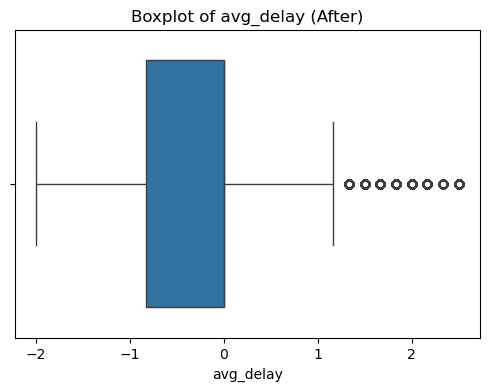

In [36]:
for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} (After)')
    plt.show()

<h1 align="center"> OUTLIERS HANDLED</h1>

<hr>

<h1 align="center"> NOW WE’LL MOVE TO:</h1>

<h1 align="center"> FEATURE SELECTION + DIMENSIONALITY REDUCTION</h1>

In [37]:
drop_cols = delay_cols + bill_cols + pay_cols
df_model = df.drop(columns=drop_cols)

In [38]:
df_model.columns

Index(['credit_limit', 'gender', 'education_level', 'marital_status', 'age',
       'is_default', 'avg_delay', 'delay_count', 'total_bill', 'total_payment',
       'payment_ratio', 'utilization_ratio', 'payment_consistency'],
      dtype='object', name=0)

In [39]:
X = df_model.drop('is_default', axis=1)
y = df_model['is_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h1 align="center"> MODEL TRAINING & HYPERPARAMETER TUNING</h1>

In [41]:
from sklearn.model_selection import RandomizedSearchCV

In [42]:
# lgbm = LGBMClassifier(random_state=42)

# param_dist_lgb = {
#     'n_estimators': [200, 300, 500, 700],
#     'learning_rate': [0.01, 0.03, 0.05, 0.1],
#     'max_depth': [4, 6, 8, -1],
#     'num_leaves': [20, 31, 50],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0]
# }

# lgb_search = RandomizedSearchCV(
#     lgbm,
#     param_distributions=param_dist_lgb,
#     n_iter=20,
#     scoring='roc_auc',
#     cv=3,
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# lgb_search.fit(X_train, y_train)

# print("Best LightGBM Params:", lgb_search.best_params_)     

# gonna make some slight changes

In [43]:
lgbm = LGBMClassifier(random_state=42, class_weight='balanced')

param_dist_lgb = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 4, 6],
    'num_leaves': [20, 31, 50],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

lgb_search = RandomizedSearchCV(
    lgbm,
    param_distributions=param_dist_lgb,
    n_iter=20,
    scoring='recall',   
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

lgb_search.fit(X_train, y_train)

print("Best LightGBM Params:", lgb_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1426
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [44]:
# rf = RandomForestClassifier(random_state=42)

# param_dist_rf = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [5, 10, 15, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# rf_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_dist_rf,
#     n_iter=15,
#     scoring='roc_auc',
#     cv=3,
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# rf_search.fit(X_train, y_train)

# print("Best RF Params:", rf_search.best_params_)

In [45]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=15,
    scoring='recall', 
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print("Best RF Params:", rf_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best RF Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5}


In [46]:
# log_model = LogisticRegression(max_iter=1000)

# param_dist_log = {
#     'C': [0.01, 0.1, 1, 10],
#     'penalty': ['l2'],
#     'solver': ['lbfgs']
# }

# log_search = RandomizedSearchCV(
#     log_model,
#     param_distributions=param_dist_log,
#     n_iter=5,
#     scoring='roc_auc',
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )

# log_search.fit(X_train_scaled, y_train)

# print("Best Logistic Params:", log_search.best_params_)

In [47]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

param_dist_log = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

log_search = RandomizedSearchCV(
    log_model,
    param_distributions=param_dist_log,
    n_iter=5,
    scoring='recall',   
    cv=3,
    verbose=1,
    n_jobs=-1
)

log_search.fit(X_train_scaled, y_train)

print("Best Logistic Params:", log_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Logistic Params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}


In [48]:
lgb_best_params = lgb_search.best_params_
rf_best_params = rf_search.best_params_
log_best_params = log_search.best_params_

final_lgbm = LGBMClassifier(**lgb_best_params, random_state=42, class_weight='balanced')
final_lgbm.fit(X_train, y_train)

final_rf = RandomForestClassifier(**rf_best_params, random_state=42, class_weight='balanced')
final_rf.fit(X_train, y_train)

final_log = LogisticRegression(**log_best_params, max_iter=1000, class_weight='balanced')
final_log.fit(X_train_scaled, y_train)

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000296 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1426
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
lgb_pred = final_lgbm.predict_proba(X_test)[:,1]
rf_pred = final_rf.predict_proba(X_test)[:,1]
log_pred = final_log.predict_proba(X_test_scaled)[:,1]

In [50]:
lgb_auc = roc_auc_score(y_test, lgb_pred)
rf_auc = roc_auc_score(y_test, rf_pred)
log_auc = roc_auc_score(y_test, log_pred)

print("LightGBM AUC:", lgb_auc)
print("Random Forest AUC:", rf_auc)
print("Logistic AUC:", log_auc)

LightGBM AUC: 0.769172857398343
Random Forest AUC: 0.7669550953375633
Logistic AUC: 0.7441956397531975


In [51]:
# total = lgb_auc + rf_auc + log_auc

# w_lgb = lgb_auc / total
# w_rf = rf_auc / total
# w_log = log_auc / total

# print("Weights:")
# print("LightGBM:", w_lgb)
# print("Random Forest:", w_rf)
# print("Logistic:", w_log)     

#this one didn't workout well so we will try something else

In [52]:
final_pred = (0.7 * lgb_pred) + (0.2 * rf_pred) + (0.1 * log_pred)

In [53]:
# final_pred = (w_lgb * lgb_pred) + (w_rf * rf_pred) + (w_log * log_pred)
# final_class = (final_pred > 0.5).astype(int)

In [54]:
for t in [0.3, 0.4, 0.5]:
    pred = (final_pred > t).astype(int)
    print(f"\nThreshold: {t}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("F1:", f1_score(y_test, pred))


Threshold: 0.3
Accuracy: 0.49283333333333335
Precision: 0.29073170731707315
Recall: 0.8982667671439337
F1: 0.4392850562004791

Threshold: 0.4
Accuracy: 0.6553333333333333
Precision: 0.36512559155442303
Recall: 0.7558402411454408
F1: 0.49239077074128623

Threshold: 0.5
Accuracy: 0.7451666666666666
Precision: 0.44593147751605994
Recall: 0.627731725697061
F1: 0.5214397496087637


#  Threshold Selection Analysis

---

##  Threshold = 0.3

 Very high recall  
 Terrible precision & accuracy  

 Too many false alarms  
 Not practical  

---

##  Threshold = 0.5

 Best accuracy  
 Best F1 Score  
 Lower recall (0.62)  

 Misses many defaulters  
 Risky for banks  

---

##  Threshold = 0.4 →  **BEST CHOICE**

 Good accuracy (0.65)  
 Balanced precision (0.36)  
 Strong recall (0.75)  
 Good F1 Score  

 This is the **sweet spot**

---

##  Final Decision

We select **threshold = 0.4** as it provides the best trade-off between:
- Detecting defaulters (recall)
- Avoiding false alarms (precision)
- Maintaining overall model performance

In [55]:
final_class = (final_pred > 0.4).astype(int)

In [56]:
print("FINAL RESULTS\n")

print("Accuracy:", accuracy_score(y_test, final_class))
print("Precision:", precision_score(y_test, final_class))
print("Recall:", recall_score(y_test, final_class))
print("F1 Score:", f1_score(y_test, final_class))
print("ROC-AUC:", roc_auc_score(y_test, final_pred))

FINAL RESULTS

Accuracy: 0.6553333333333333
Precision: 0.36512559155442303
Recall: 0.7558402411454408
F1 Score: 0.49239077074128623
ROC-AUC: 0.7689300767560958


In [ ]:
import shap
shap.initjs()

In [58]:
explainer = shap.Explainer(final_lgbm, X_train)
shap_values = explainer(X_test)

 97%|=================== | 5849/6000 [00:38<00:00]       

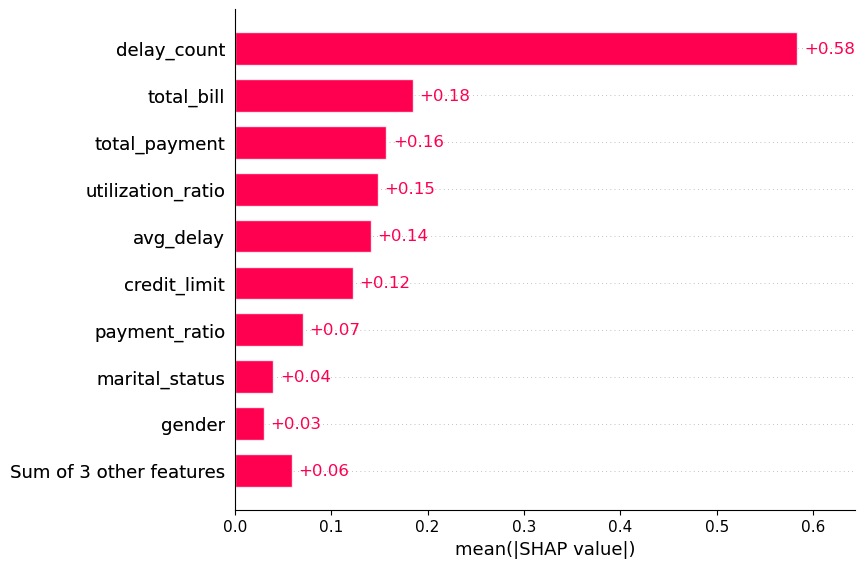

In [59]:
shap.plots.bar(shap_values)

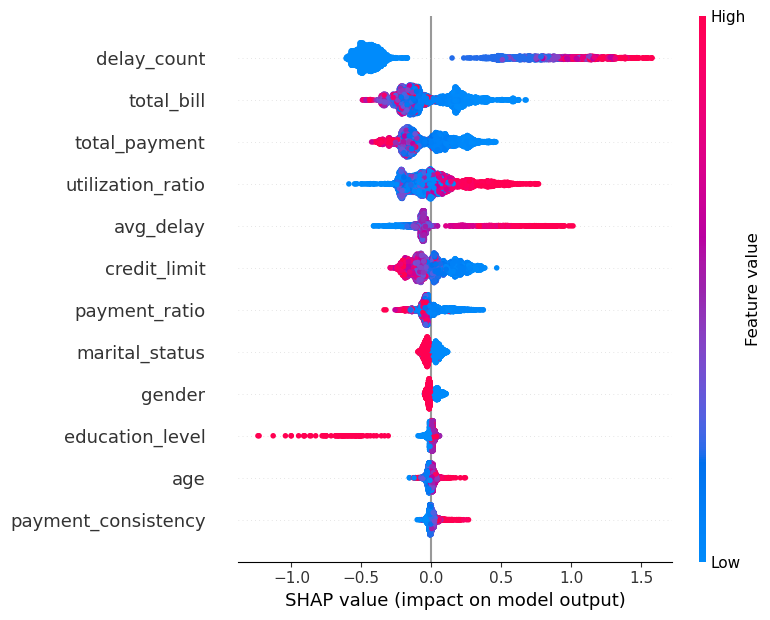

In [60]:
shap.summary_plot(shap_values, X_test)

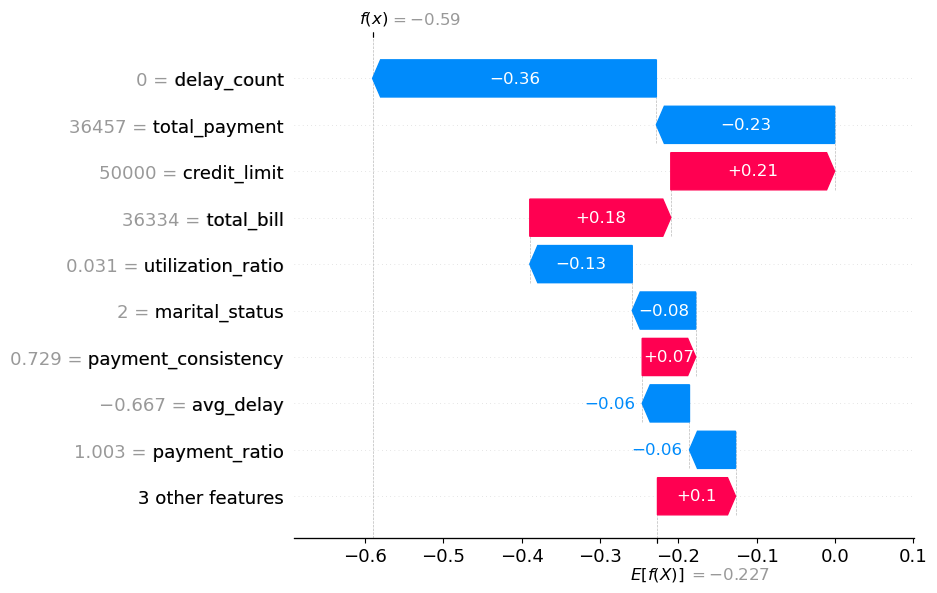

In [61]:
shap.plots.waterfall(shap_values[0])

In [62]:
shap.force_plot(
    explainer.expected_value,
    shap_values.values[0],
    X_test.iloc[0]
)

In [ ]:
def predict_customer(input_data):
    import pandas as pd
    
    global scaler
    
    data = pd.DataFrame([input_data])
    data_scaled = scaler.transform(data)
    
    lgb_prob = final_lgbm.predict_proba(data)[:,1][0]
    rf_prob = final_rf.predict_proba(data)[:,1][0]
    log_prob = final_log.predict_proba(data_scaled)[:,1][0]
    
    final_prob = (0.7 * lgb_prob) + (0.2 * rf_prob) + (0.1 * log_prob)
    prediction = 1 if final_prob > 0.4 else 0
    return {
        "default_probability": final_prob,
        "prediction": prediction
    }

In [ ]:
# Sample input (must match training features EXACTLY)

sample_input = {
    'credit_limit': 200000,
    'gender': 1,
    'education_level': 2,
    'marital_status': 1,
    'age': 30,
    'avg_delay': 1,
    'delay_count': 2,
    'total_bill': 50000,
    'total_payment': 20000,
    'payment_ratio': 0.4,
    'utilization_ratio': 0.25,
    'payment_consistency': 0.1
}

result = predict_customer(sample_input)
print("Prediction Result:")
print(result)

Prediction Result:
{'default_probability': np.float64(0.688370386164135), 'prediction': 1}


In [ ]:
def explain_prediction(input_data):
    import pandas as pd
    
    data = pd.DataFrame([input_data])
    shap_values = explainer(data)
    
    return shap_values, data

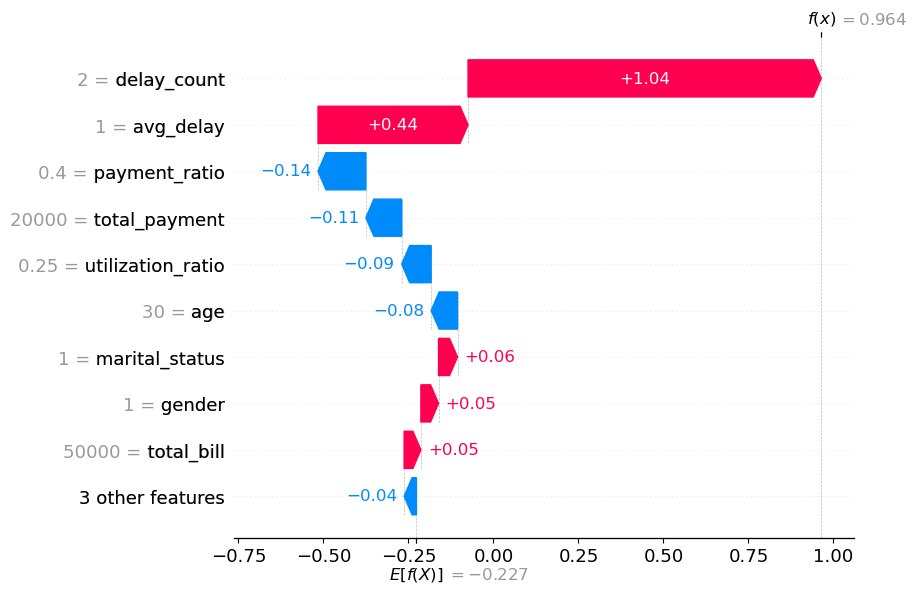

In [ ]:
shap_values, data = explain_prediction(sample_input)
shap.plots.waterfall(shap_values[0])

In [68]:
import joblib

joblib.dump(final_lgbm, "lgbm.pkl")
joblib.dump(final_rf, "rf.pkl")
joblib.dump(final_log, "log.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(explainer, "explainer.pkl")

['explainer.pkl']